# 03 - Clustering: Attribute-Based Player Archetypes

Rather than relying on the position labels FC26 assigns, can we recover meaningful player
*archetypes* directly from the six core attribute categories (`pace`, `shooting`, `passing`,
`dribbling`, `defending`, `physic`)? This notebook standardizes those attributes, reduces
them to 2D with PCA for visualization, and uses KMeans to assign each player to one of a
handful of data-driven archetypes - then labels each cluster by inspecting its attribute
profile and representative players.

Goalkeepers don't have these six outfield attributes populated in the source data, so they
are naturally excluded from clustering (dropped via `dropna`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/players_fc26_clean.csv")
ATTRS = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]

cl = df.dropna(subset=ATTRS).copy()
print(f"{len(cl):,} outfield players with complete attribute data "
      f"({len(df) - len(cl):,} excluded, mostly goalkeepers)")
cl[ATTRS].describe().round(1)

16,343 outfield players with complete attribute data (2,062 excluded, mostly goalkeepers)


,pace,shooting,passing,dribbling,defending,physic
count,16343.0,16343.0,16343.0,16343.0,16343.0,16343.0
mean,68.4,52.8,57.6,62.9,52.0,64.8
std,10.5,13.9,9.9,9.4,16.2,9.7
min,30.0,21.0,25.0,22.0,15.0,32.0
25%,62.0,42.0,51.0,57.0,38.0,58.0
50%,69.0,55.0,58.0,64.0,57.0,66.0
75%,75.0,63.0,64.0,69.0,64.0,72.0
max,97.0,92.0,92.0,93.0,90.0,91.0


## Position groups (for reference / coloring only)

Position groups are used later purely to sanity-check and color the clusters - they are
**not** used as clustering features, since the whole point is to see whether attribute
profiles alone recover position-like (or cross-position) structure.

In [2]:
POSITION_GROUP = {
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

cl["primary_position"] = cl["player_positions"].apply(primary_position)
cl["position_group"] = cl["primary_position"].map(POSITION_GROUP)
cl["position_group"].value_counts(dropna=False)

position_group
Midfielder    6864
Defender      6116
Attacker      3363
Name: count, dtype: int64

## Standardize + PCA

The six attributes are on the same 0-99 scale, but with different spreads (e.g. `defending`
varies far more across the player pool than `physic`), so we standardize before PCA/KMeans
to avoid attributes with larger variance dominating the distance metric.

In [3]:
scaler = StandardScaler()
X = cl[ATTRS].values
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
cl["pca1"] = X_pca[:, 0]
cl["pca2"] = X_pca[:, 1]

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"cumulative={pca.explained_variance_ratio_[:2].sum():.1%}")

loadings = pd.DataFrame(pca.components_.T, index=ATTRS, columns=["PC1", "PC2"])
loadings.round(2)

Explained variance ratio: PC1=46.9%, PC2=28.5%, cumulative=75.4%


,PC1,PC2
pace,0.36,-0.22
shooting,0.52,-0.10
passing,0.51,0.29
dribbling,0.57,0.08
defending,-0.11,0.68
physic,0.02,0.62


**Takeaway:** the first two principal components already capture the large majority of
the variance in the six-attribute space. PC1 loads positively on nearly every attribute
(it's essentially an "overall quality/all-around ability" axis), while PC2 separates
attacking attributes (pace, shooting, dribbling) from defensive ones (defending, physic) -
i.e. a "attacker vs. defender" axis. This 2D structure is why a simple PCA scatter is such a
useful visualization for archetype clusters below.

## Choosing k

We try KMeans for a range of cluster counts (`k`) and compare inertia (elbow method) and
mean silhouette score (computed on a 5,000-player sample for speed) to pick a `k` that is
both statistically reasonable and produces footballing-sensible, interpretable archetypes.

In [4]:
results = []
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette
0,3,52674.905742,0.267782
1,4,46004.786739,0.238419
2,5,41105.113997,0.213275
3,6,37955.923890,0.211969
4,7,35112.100078,0.216357
5,8,32948.951790,0.211229
6,9,30918.678148,0.200654
7,10,29203.220267,0.201707


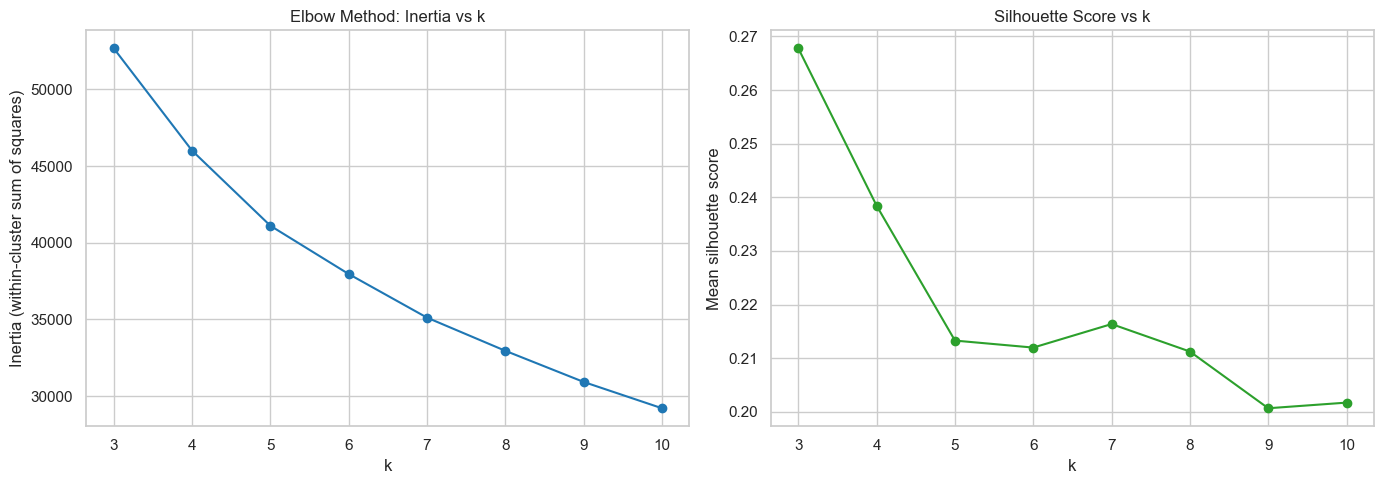

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["k"], results_df["inertia"], marker="o", color="#1f77b4")
axes[0].set_title("Elbow Method: Inertia vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")

axes[1].plot(results_df["k"], results_df["silhouette"], marker="o", color="#2ca02c")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean silhouette score")

plt.tight_layout()
plt.show()

**Takeaway:** silhouette score is highest at k=3 (which just recovers the coarse
attacker/midfielder/defender split) and decays smoothly afterward, with a small local bump
around k=6-7. Since the goal is *interpretable, football-meaningful archetypes* rather than
the single mathematically tightest partition, we pick **k=6**: it sits at a natural
inertia-elbow point, keeps a reasonable silhouette score, and - as shown below - produces
six clusters with clearly distinct, nameable attribute profiles.

In [6]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
cl["cluster"] = kmeans.labels_

cluster_profile = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), columns=ATTRS
)
cluster_profile["count"] = cl["cluster"].value_counts().sort_index().values
cluster_profile.round(1)

,pace,shooting,passing,dribbling,defending,physic,count
0,69.0,52.0,52.6,59.9,36.5,50.2,2501
1,68.9,63.0,69.3,71.5,65.9,71.4,3002
2,57.6,32.2,45.0,48.5,61.3,67.5,2675
3,67.9,64.3,52.4,62.7,29.4,68.2,1640
4,68.2,46.1,57.9,61.9,62.4,68.0,3980
5,79.0,66.4,65.0,72.3,39.1,61.2,2545


## Labeling the archetypes

Inspecting each cluster's mean attribute profile and its highest-`overall` representative
players (below) suggests six clear archetypes:

| Cluster | Archetype | Profile |
|---|---|---|
| 0 | **Developing Playmaker** | Modest across the board (overall ~68-70), lowest `physic`, low `defending`; fringe attacking mid/wide players still developing |
| 1 | **Elite All-Rounder** | Highest attributes almost across the board (`overall` 85-90+); the best players in the game regardless of position - Bellingham, Rodri, Haaland, van Dijk, Kimmich, Hakimi |
| 2 | **No-Nonsense Stopper** | Low `pace`/`shooting`/`dribbling`, high `defending`/`physic`; classic old-school stay-at-home centre-backs |
| 3 | **Target Forward** | High `shooting`/`physic`, lowest `defending`, modest `passing`; out-and-out strikers built to finish, not build play |
| 4 | **Ball-Playing Centre-Back** | High `defending`/`physic` like cluster 2, but with more `pace`/`dribbling` - modern, mobile centre-backs comfortable on the ball |
| 5 | **Pacey Inside Forward** | Highest `pace`, high `shooting`/`dribbling`, low `defending`; explosive wide attackers - Salah, Mbappe, Vinicius, Yamal |

Cluster 1 is notable for cutting *across* traditional positions - it's really an "elite
quality" cluster rather than a positional one, since world-class players at any position
tend to be well-rounded across all six attributes relative to their peers.

In [7]:
CLUSTER_LABELS = {
    0: "Developing Playmaker",
    1: "Elite All-Rounder",
    2: "No-Nonsense Stopper",
    3: "Target Forward",
    4: "Ball-Playing Centre-Back",
    5: "Pacey Inside Forward",
}
cl["archetype"] = cl["cluster"].map(CLUSTER_LABELS)
cl["archetype"].value_counts()

archetype
Ball-Playing Centre-Back    3980
Elite All-Rounder           3002
No-Nonsense Stopper         2675
Pacey Inside Forward        2545
Developing Playmaker        2501
Target Forward              1640
Name: count, dtype: int64

### Representative players per archetype

In [8]:
for c in range(K):
    label = CLUSTER_LABELS[c]
    top = cl[cl["cluster"] == c].sort_values("overall", ascending=False).head(5)
    print(f"--- Cluster {c}: {label} ---")
    print(top[["short_name", "player_positions", "overall"] + ATTRS].to_string(index=False))
    print()

--- Cluster 0: Developing Playmaker ---
    short_name player_positions  overall  pace  shooting  passing  dribbling  defending  physic
Jaimosa Cavaco           RB, RM       70  72.0      63.0     52.0       57.0       66.0    47.0
      M. Marín          CAM, CM       69  67.0      64.0     66.0       69.0       27.0    40.0
 S. Amo-Ameyaw           RM, RW       69  77.0      58.0     63.0       73.0       28.0    41.0
      A. Amado          CM, CAM       69  69.0      56.0     64.0       72.0       65.0    40.0
         Chuki      CAM, LM, CM       68  68.0      64.0     62.0       69.0       35.0    47.0

--- Cluster 1: Elite All-Rounder ---
   short_name player_positions  overall  pace  shooting  passing  dribbling  defending  physic
J. Bellingham          CAM, CM       90  80.0      86.0     83.0       90.0       78.0    85.0
        Rodri          CDM, CM       90  65.0      80.0     86.0       84.0       86.0    85.0
   E. Haaland               ST       90  86.0      91.0     7

## PCA scatter, colored by archetype

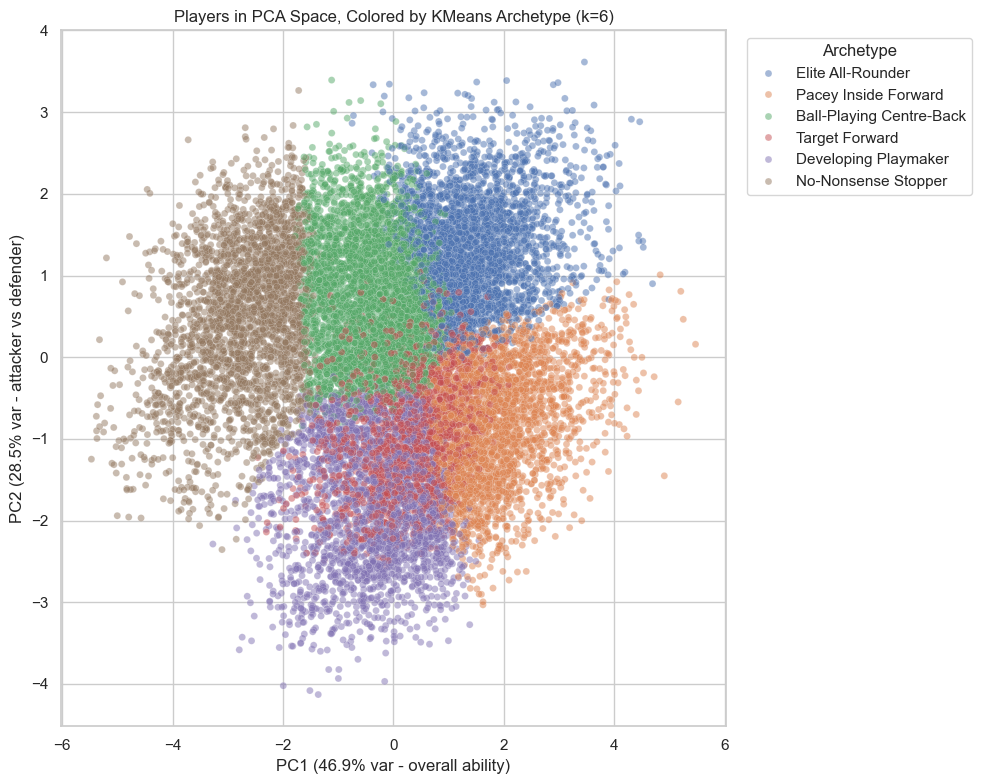

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=cl, x="pca1", y="pca2", hue="archetype", palette="deep",
    alpha=0.5, s=25, edgecolor="white", linewidth=0.2, ax=ax,
)
ax.set_title(f"Players in PCA Space, Colored by KMeans Archetype (k={K})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var - overall ability)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var - attacker vs defender)")
ax.legend(title="Archetype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## PCA scatter, colored by position group (for comparison)

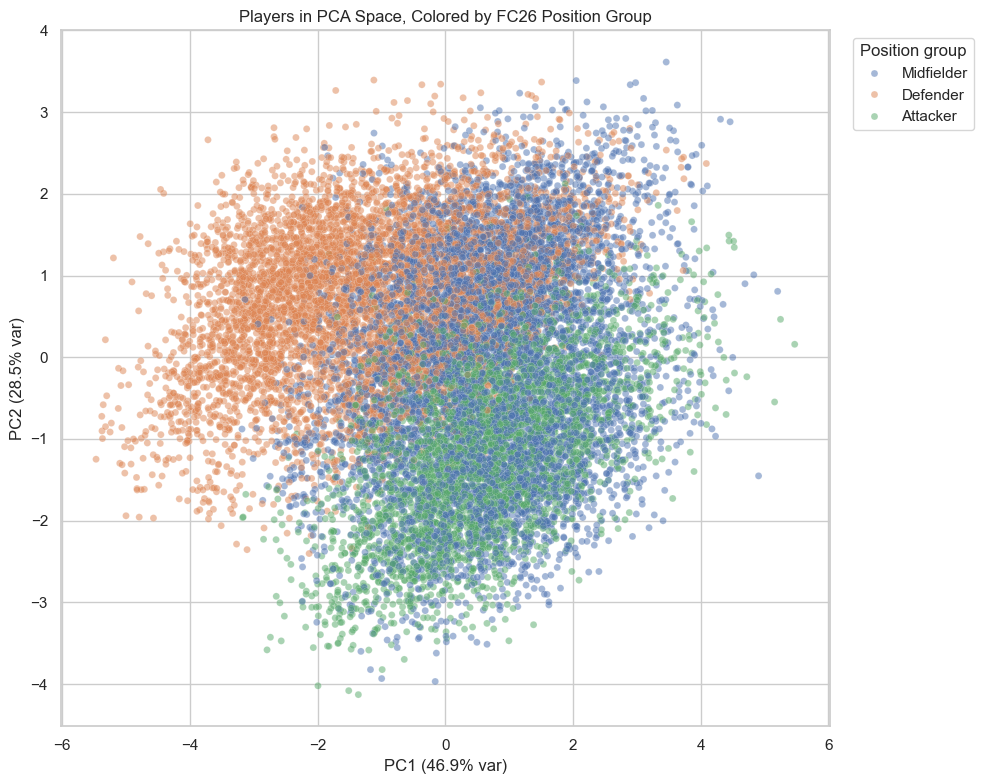

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=cl.dropna(subset=["position_group"]), x="pca1", y="pca2", hue="position_group",
    palette="deep", alpha=0.5, s=25, edgecolor="white", linewidth=0.2, ax=ax,
)
ax.set_title("Players in PCA Space, Colored by FC26 Position Group")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.legend(title="Position group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
cross_tab = pd.crosstab(cl["archetype"], cl["position_group"], normalize="index").round(2)
cross_tab

position_group,Attacker,Defender,Midfielder
archetype,,,
Ball-Playing Centre-Back,0.01,0.63,0.37
Developing Playmaker,0.32,0.09,0.59
Elite All-Rounder,0.05,0.29,0.67
No-Nonsense Stopper,0.00,0.93,0.07
Pacey Inside Forward,0.35,0.02,0.63
Target Forward,0.92,0.00,0.08


**Takeaway:** the two scatters (archetype vs. position group) have visibly similar
shapes along PC2 (the attacker/defender axis), confirming clustering recovers real
footballing structure rather than noise. But it's not a 1:1 remap of position labels -
**Elite All-Rounder** pulls the very best players from *every* position group into one
cluster (its cross-tab row spreads across Defender/Midfielder/Attacker rather than
concentrating in one), while **No-Nonsense Stopper** vs. **Ball-Playing Centre-Back** splits
what FC26 lumps together as a single `CB` position into two distinct playing styles based on
mobility and ball-playing ability - exactly the kind of nuance attribute-based clustering is
supposed to surface beyond a raw position label.

## Archetype quality: overall rating by cluster

C:\Users\thoma\AppData\Local\Temp\ipykernel_1548\3022901384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cl, x="archetype", y="overall", order=order, ax=ax, palette="deep")


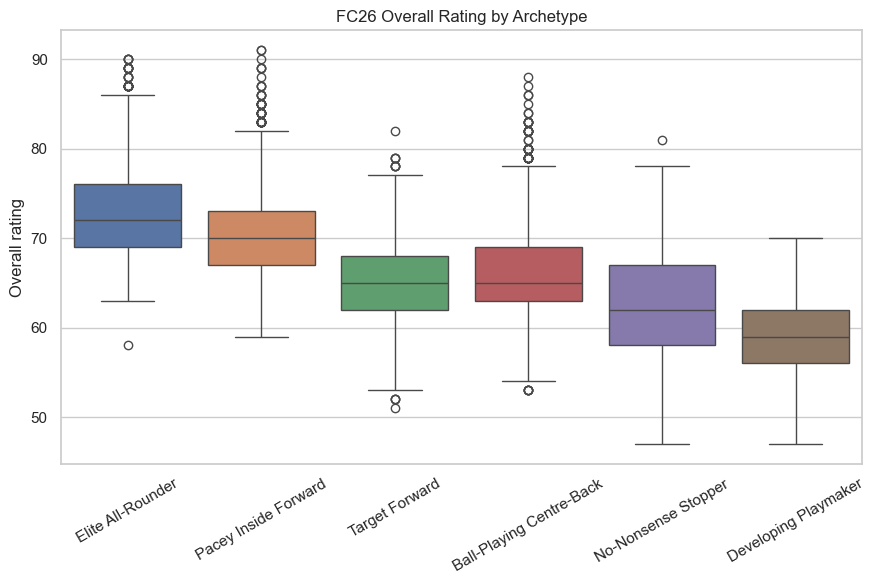

,count,mean,median
archetype,,,
Elite All-Rounder,3002,72.6,72.0
Pacey Inside Forward,2545,70.5,70.0
Target Forward,1640,65.0,65.0
Ball-Playing Centre-Back,3980,65.8,65.0
No-Nonsense Stopper,2675,62.1,62.0
Developing Playmaker,2501,58.3,59.0


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
order = cl.groupby("archetype")["overall"].median().sort_values(ascending=False).index
sns.boxplot(data=cl, x="archetype", y="overall", order=order, ax=ax, palette="deep")
ax.set_title("FC26 Overall Rating by Archetype")
ax.set_xlabel("")
ax.set_ylabel("Overall rating")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

cl.groupby("archetype")["overall"].agg(["count", "mean", "median"]).loc[order].round(1)

**Takeaway:** as the name suggests, **Elite All-Rounder** has by far the highest median
overall rating of any archetype, well above the other five clusters - it's effectively
capturing "top-tier player at any position" rather than a single tactical role. The other
five archetypes cluster much closer together in overall rating, since they mostly separate
players by *playing style* rather than by *quality tier*.

## Summary

- Six data-driven archetypes emerge cleanly from just six attribute categories: Developing
  Playmaker, Elite All-Rounder, No-Nonsense Stopper, Target Forward, Ball-Playing
  Centre-Back, and Pacey Inside Forward.
- PC1 is essentially an "overall ability" axis and PC2 an "attacker vs. defender" axis,
  together explaining the large majority of variance in the six-attribute space.
- Clustering both confirms known football structure (attackers, midfielders, and defenders
  separate cleanly along PC2) and adds nuance beyond FC26's own position labels - splitting
  centre-backs into mobile ball-players vs. traditional stoppers, and pulling elite players
  of *any* position into their own "Elite All-Rounder" tier.
- k=6 was chosen as a balance between silhouette/inertia diagnostics and producing
  interpretable, footballing-sensible clusters rather than chasing the single best
  statistical score (which favored a much coarser k=3 split).